In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import preprocessing
from sklearn import set_config

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.compose import TransformedTargetRegressor
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer

from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.feature_selection import SelectPercentile, chi2

from sklearn.metrics import r2_score, mean_squared_error,accuracy_score, make_scorer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_parquet("../data/diamonds.parquet")

In [3]:
df

,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,culet_size,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,N,...,1.79,M,M,unknown,unknown,unknown,unknown,unknown,unknown,200
1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,N,...,1.78,STK,STK,unknown,unknown,unknown,unknown,unknown,unknown,200
2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,...,1.77,TN,M,unknown,unknown,unknown,unknown,unknown,unknown,200
3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,...,1.78,M,STK,unknown,unknown,unknown,unknown,unknown,unknown,200
4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,N,...,1.82,STK,STK,unknown,unknown,unknown,unknown,unknown,unknown,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219699,Round,E,VS1,10.65,Excellent,GIA,Excellent,Excellent,unknown,N,...,8.66,M,STK,unknown,unknown,unknown,unknown,unknown,unknown,1210692
219700,Radiant,unknown,VS2,5.17,unknown,GIA,Very Good,Very Good,unknown,unknown,...,5.71,TK,XTK,unknown,unknown,Green,unknown,unknown,Fancy Light,1292500
219701,Round,E,VS1,18.07,Excellent,GIA,Excellent,Excellent,unknown,N,...,10.20,TN,M,unknown,unknown,unknown,unknown,unknown,unknown,1315496
219702,Princess,unknown,SI2,0.90,unknown,GIA,Good,Good,unknown,N,...,3.47,XTN,VTK,unknown,Faint,Red,unknown,unknown,Fancy,1350000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219704 entries, 0 to 219703
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   cut                          219704 non-null  object 
 1   color                        219704 non-null  object 
 2   clarity                      219704 non-null  object 
 3   carat_weight                 219704 non-null  float64
 4   cut_quality                  219704 non-null  object 
 5   lab                          219704 non-null  object 
 6   symmetry                     219704 non-null  object 
 7   polish                       219704 non-null  object 
 8   eye_clean                    219704 non-null  object 
 9   culet_size                   219704 non-null  object 
 10  culet_condition              219704 non-null  object 
 11  depth_percent                219704 non-null  float64
 12  table_percent                219704 non-null  float64
 13  meas

## Define the categories for transformations

We have numerical columns as well as categorical columns both of ordinal and nominal subtypes

#### Numerical 

In [5]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
#numerical_columns

#### Ordinals

In [6]:
ordinal_columns = ['clarity', 'culet_size', 'cut_quality', 'polish', 'symmetry']

In [7]:
clarity_ord = ['F', 'IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1',  'SI2', 'SI3', 'I1', 'I2','I3']
culet_size_ord = ['N', 'VS', 'S', 'M', 'SL', 'L', 'VL', 'EL', 'unknown']
cut_quality_ord = ['Ideal', 'Excellent',  'Very Good', 'Good', 'Fair', 'None', 'unknown']
polish_ord = ['Excellent','Very Good', 'Good', 'Fair', 'Poor']
symmetry_ord = ['Excellent','Very Good', 'Good', 'Fair', 'Poor']

#### Nominals

In [8]:
nominal_columns = ['cut', 'color','lab','eye_clean','culet_condition',\
                   'girdle_max', 'girdle_min',\
                   'fancy_color_intensity','fancy_color_dominant_color',\
                   'fancy_color_secondary_color','fancy_color_overtone',\
                   'fluor_color', 'fluor_intensity']
            
# for col in nominal_columns:
#     print(f" '{col}' has the following values: \n \t {df[col].unique()} \n")

#### From the course we know regression models don't do well with long tails. From the EDA notebook we know this has a very loooooong tail.

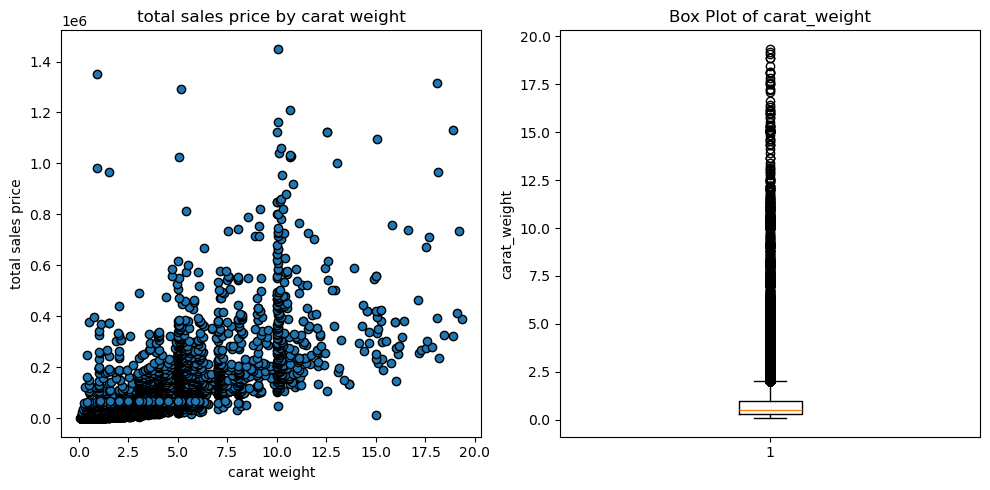

In [9]:
# Create the Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Histogram (price by carat weight)
ax1.scatter(x=df['carat_weight'], y=df['total_sales_price'],  edgecolor='black')
ax1.set_xlabel('carat weight')
ax1.set_ylabel('total sales price')
ax1.set_title('total sales price by carat weight')

# Box Plot (Whiskers)
ax2.boxplot(df['carat_weight'])
ax2.set_ylabel('carat_weight')
ax2.set_title('Box Plot of carat_weight')

# sns.set_palette(palette='dark', n_colors=14)
# df['carat_weight'].plot(kind='box',figsize=(20,20),subplots=True,layout=(3,3))

# plt.show()

# Adjust Layout
plt.tight_layout()

# Display the Plots
plt.show()

#### We can try splitting this with everything in the box and whiskers as one model and eveything above that as another. <br> 
AND/OR <br> 
#### We can try taking the log of the prices to regularize it. Let's try in that order. 

In [10]:
df['carat_weight'].describe()

count    219704.000000
mean          0.755176
std           0.845892
min           0.080000
25%           0.310000
50%           0.500000
75%           1.000000
max          19.350000
Name: carat_weight, dtype: float64

In [11]:
df['total_sales_price'].describe()

count    2.197040e+05
mean     6.908035e+03
std      2.595944e+04
min      2.000000e+02
25%      9.580000e+02
50%      1.970000e+03
75%      5.207000e+03
max      1.449881e+06
Name: total_sales_price, dtype: float64

In [12]:
Q1_price, Q3_price = df['total_sales_price'].quantile(.25), df['total_sales_price'].quantile(.75)
IQR_price = Q3_price - Q1_price
IQR_price

np.float64(4249.0)

In [13]:
upper_lim_price = Q3_price + 1.5*IQR_price
upper_lim_price

np.float64(11580.5)

In [14]:
Q1_carat_weight, Q3_carat_weight = df['carat_weight'].quantile(.25), df['carat_weight'].quantile(.75)
IQR_carat_weight = Q3_carat_weight - Q1_carat_weight
IQR_carat_weight

np.float64(0.69)

In [15]:
upper_lim_carat_weight = Q3_carat_weight + 1.5*IQR_carat_weight
upper_lim_carat_weight

np.float64(2.035)

#### So the cutoff points are $11,580 and 2.04 carats. We can now see if splitting into two models will work. Let's try price.

In [16]:
filtered_df_low_price = df[df['total_sales_price'] < 11580]

In [17]:
filtered_df_high_price = df[df['total_sales_price'] > 11580]

In [18]:
filtered_df_low_cw = df[df['carat_weight'] < 2.04]

In [19]:
filtered_df_high_cw = df[df['carat_weight'] > 2.04]

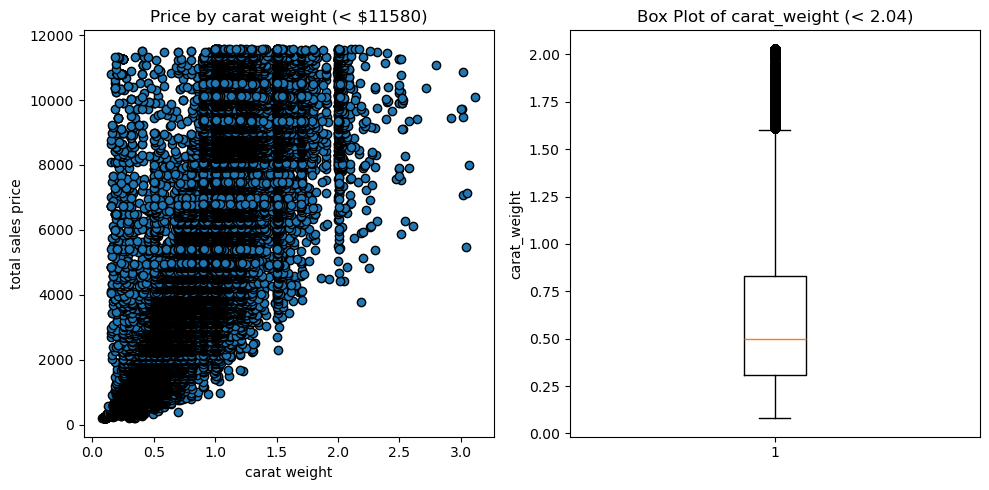

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Histogram
ax1.scatter(x=filtered_df_low_price['carat_weight'], y=filtered_df_low_price['total_sales_price'],  edgecolor='black')
ax1.set_xlabel('carat weight')
ax1.set_ylabel('total sales price')
ax1.set_title('Price by carat weight (< $11580)')

# Box Plot (Whiskers)
ax2.boxplot(filtered_df_low_cw['carat_weight'])
ax2.set_ylabel('carat_weight')
ax2.set_title('Box Plot of carat_weight (< 2.04)')

# Adjust Layout
plt.tight_layout()

# Display the Plots
plt.show()

OK, that's ... not as helpful as I was hoping. Perhaps the stones above the cutoff will look better.

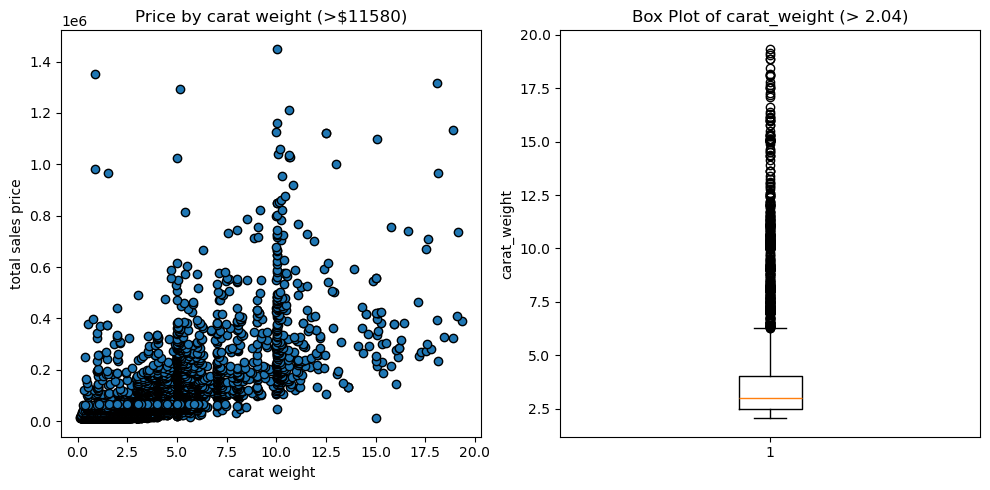

In [21]:
# Create the Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Histogram
ax1.scatter(x=filtered_df_high_price['carat_weight'], y=filtered_df_high_price['total_sales_price'],  edgecolor='black')
ax1.set_xlabel('carat weight')
ax1.set_ylabel('total sales price')
ax1.set_title('Price by carat weight (>$11580)')

# Box Plot (Whiskers)
ax2.boxplot(filtered_df_high_cw['carat_weight'])
ax2.set_ylabel('carat_weight')
ax2.set_title('Box Plot of carat_weight (> 2.04)')

# Adjust Layout
plt.tight_layout()

# Display the Plots
plt.show()

#### OK, that's not any better and together they show we're not going to be able to make this work by just splitting it into two models using either price or carat weight. We're going to need to try something else so let's go with the log of prices and/or carat weight.

#### So there's a .15 carat diamond that's above the cutoff point which was 1.5 times the IQR?

In [22]:
ripoff = df[(df['total_sales_price'] > 11580) & (df['carat_weight'] < .2)]
ripoff

,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,culet_size,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
192450,Cushion Modified,unknown,I1,0.19,unknown,GIA,Good,Very Good,unknown,unknown,...,2.04,M,XTK,Blue,Medium,Pink,unknown,unknown,Fancy Intense,11970
192451,Cushion Modified,unknown,VS2,0.19,unknown,GIA,Good,Very Good,unknown,unknown,...,2.20,XTK,XTK,Blue,Strong,Pink,unknown,unknown,Fancy Intense,11970
192894,Oval,unknown,SI1,0.15,unknown,GIA,Very Good,Very Good,unknown,unknown,...,1.86,unknown,unknown,Blue,Medium,Pink,unknown,unknown,Fancy Intense,12150
199359,Cushion Modified,unknown,SI1,0.19,unknown,GIA,Very Good,Excellent,unknown,N,...,1.94,XTN,XTK,unknown,Faint,Pink,unknown,unknown,Fancy Intense,13680
200018,Radiant,unknown,VVS2,0.18,unknown,GIA,Good,Very Good,unknown,unknown,...,1.91,STK,XTK,unknown,Faint,Pink,unknown,unknown,Fancy Deep,16200
200035,Emerald,unknown,VS1,0.15,unknown,GIA,Good,Good,unknown,N,...,1.58,M,VTK,unknown,Faint,Pink,unknown,unknown,Fancy Intense,16200
210930,Marquise,unknown,SI2,0.16,unknown,GIA,Good,Very Good,unknown,unknown,...,1.64,VTK,XTK,unknown,Faint,Gray,unknown,unknown,Fancy,24320


#### NO KIDDING?!? <br> 
Man, they must have seen those poor folks comming. Wow.
<br> Well, anyway. Maybe regularizing the prices will work better

In [23]:
df['log_cw'] = np.log(df['carat_weight'])

In [24]:
df['log_price'] = np.log(df['total_sales_price'])

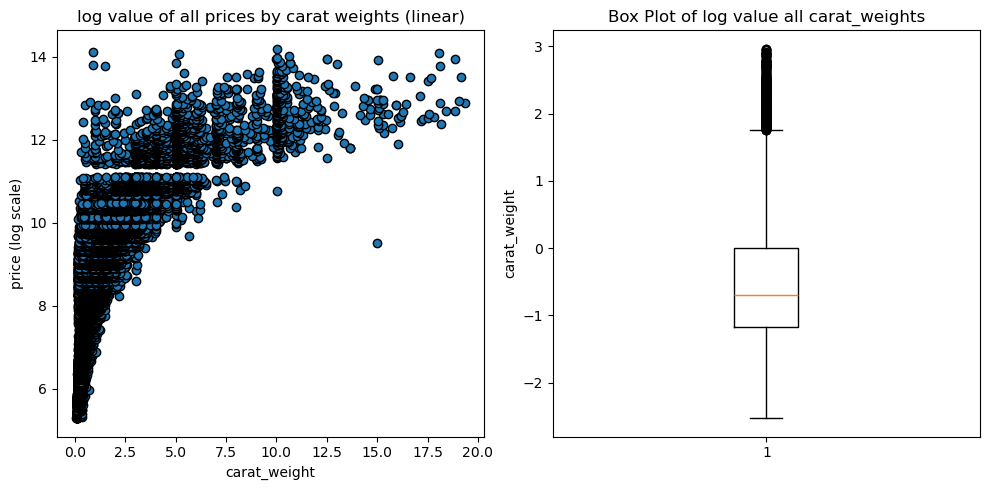

In [25]:
# Create the Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Histogram
ax1.scatter(x=df['carat_weight'], y=df['log_price'],  edgecolor='black')
ax1.set_xlabel('carat_weight')
ax1.set_ylabel('price (log scale)')
ax1.set_title('log value of all prices by carat weights (linear)')

# Box Plot (Whiskers)
ax2.boxplot(df['log_cw'])
ax2.set_ylabel('carat_weight')
ax2.set_title('Box Plot of log value all carat_weights')

# Adjust Layout
plt.tight_layout()

# Display the Plots
plt.show()

#### This is considerably better but there still are a lot of outliers. Lets's see what carat weight by price with both using log scale look like. No matter what, it still means we need to deal with the carat_weight outliers.

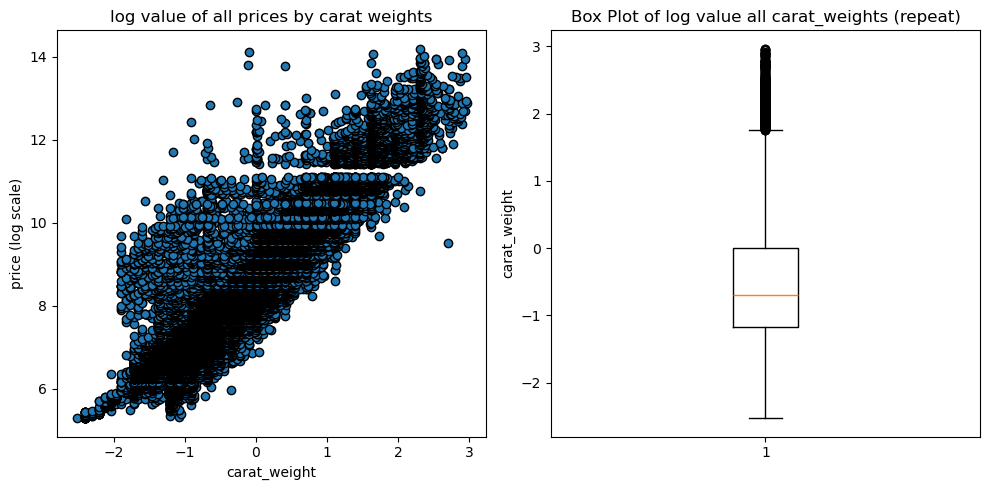

In [26]:
# Create the Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Histogram
ax1.scatter(x=df['log_cw'], y=df['log_price'],  edgecolor='black')
ax1.set_xlabel('carat_weight')
ax1.set_ylabel('price (log scale)')
ax1.set_title('log value of all prices by carat weights')

# Box Plot (Whiskers)
ax2.boxplot(df['log_cw'])
ax2.set_ylabel('carat_weight')
ax2.set_title('Box Plot of log value all carat_weights (repeat)')

# Adjust Layout
plt.tight_layout()

# Display the Plots
plt.show()

#### Ok, so regularization is needed here for sure. And I might as well do it for all the numeric columns.

#### I have two thoughts for this too. One is to use the outlier cutoff, the other is to YOLO it. >90% of the diamonds are < 2.5 carats. But, it's not really data science if you're not sciencing it. So, both it is. But I'm going to go with the cutoff at 2.5 carats. As for why carat weight when price will be used for prediction, I see less variation in it. 

In [37]:
solution_90 = df[df['carat_weight'] < 2.5]
solution_90

,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,culet_size,...,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price,log_cw,log_price
0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,N,...,M,unknown,unknown,unknown,unknown,unknown,unknown,200,-2.407946,5.298317
1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,N,...,STK,unknown,unknown,unknown,unknown,unknown,unknown,200,-2.407946,5.298317
2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,...,M,unknown,unknown,unknown,unknown,unknown,unknown,200,-2.407946,5.298317
3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,...,STK,unknown,unknown,unknown,unknown,unknown,unknown,200,-2.407946,5.298317
4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,N,...,STK,unknown,unknown,unknown,unknown,unknown,unknown,200,-2.407946,5.298317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219525,Radiant,unknown,VS1,0.76,unknown,GIA,Good,Very Good,unknown,N,...,XTK,unknown,unknown,Blue,unknown,unknown,Fancy Intense,399000,-0.274437,12.896717
219560,Oval,unknown,VS1,2.01,unknown,GIA,Good,Very Good,unknown,N,...,XTK,unknown,unknown,Pink,unknown,unknown,Fancy,439688,0.698135,12.993821
219684,Pear,unknown,VS2,1.51,unknown,GIA,Very Good,Very Good,unknown,N,...,unknown,unknown,Faint,Purple,Pink,unknown,Fancy Intense,966401,0.412110,13.781334
219685,Radiant,unknown,I1,0.89,unknown,GIA,Good,Good,unknown,N,...,VTK,Blue,Medium,Red,unknown,unknown,Fancy,982560,-0.116534,13.797917


In [28]:
solution_90.columns

Index(['cut', 'color', 'clarity', 'carat_weight', 'cut_quality', 'lab',
       'symmetry', 'polish', 'eye_clean', 'culet_size', 'culet_condition',
       'depth_percent', 'table_percent', 'meas_length', 'meas_width',
       'meas_depth', 'girdle_min', 'girdle_max', 'fluor_color',
       'fluor_intensity', 'fancy_color_dominant_color',
       'fancy_color_secondary_color', 'fancy_color_overtone',
       'fancy_color_intensity', 'total_sales_price', 'log_cw', 'log_price'],
      dtype='object')

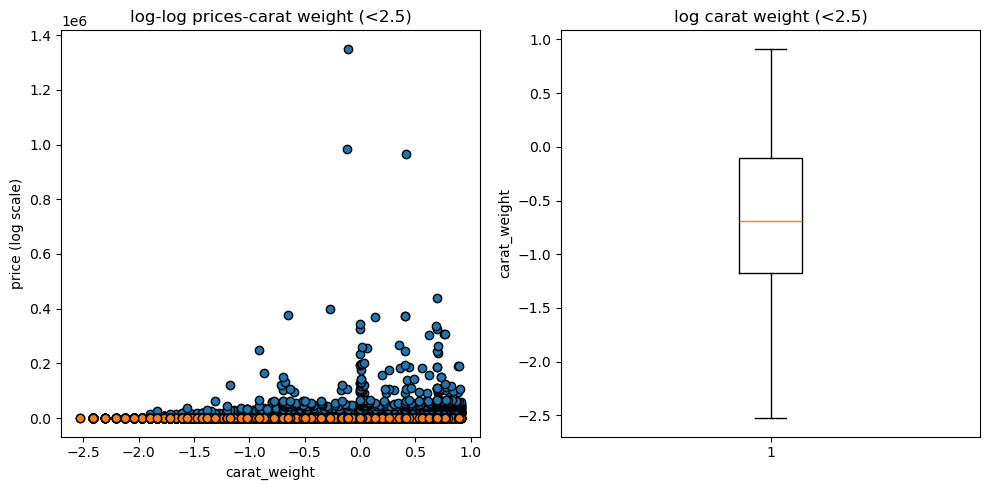

In [29]:
# Create the Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Histogram
ax1.scatter(x=solution_90['log_cw'], y=solution_90['total_sales_price'],  edgecolor='black')

#ax1.scatter(x=df['carat_weight'], y=df['log_price'],  edgecolor='black')


# Histogram
ax1.scatter(x=solution_90['log_cw'], y=solution_90['log_price'],  edgecolor='black')
ax1.set_xlabel('carat_weight')
ax1.set_ylabel('price (log scale)')
ax1.set_title('log-log prices-carat weight (<2.5)')

# Box Plot (Whiskers)
ax2.boxplot(solution_90['log_cw'])
ax2.set_ylabel('carat_weight')
ax2.set_title('log carat weight (<2.5)')

# Adjust Layout
plt.tight_layout()

# Display the Plots
plt.show()



Yeah, I can work with that. I need to think about the price outliers part. The goal is to predict prices accurately. Getting rid of some outliers makes sense because they would be way overpriced. Before I commit to that, I need to see what > 2.5 stones looks like and what the difference going with the cutoff point does.

In [36]:
super_90 = df[df['carat_weight'] > 2.5]
super_90

,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,culet_size,...,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price,log_cw,log_price
165563,Oval,unknown,I2,3.04,unknown,GIA,Very Good,Very Good,unknown,N,...,unknown,Blue,Medium,Brown,Yellow,unknown,Fancy Light,5472,1.111858,8.607399
168479,Cushion Modified,unknown,SI1,2.61,unknown,GIA,Excellent,Excellent,unknown,unknown,...,XTK,unknown,Faint,Brown,unknown,unknown,Fancy,6108,0.959350,8.717355
169773,Cushion Modified,unknown,I2,2.51,unknown,GIA,Fair,Very Good,unknown,N,...,unknown,unknown,unknown,Brown,unknown,unknown,Fancy Dark,5874,0.920283,8.678291
173011,Round,G,I3,2.55,Very Good,GIA,Very Good,Very Good,Yes,N,...,STK,unknown,unknown,unknown,unknown,unknown,unknown,6268,0.936093,8.743213
174449,Cushion Modified,unknown,I2,3.02,unknown,GIA,Good,Very Good,unknown,unknown,...,unknown,Green,Medium,Yellow,Green,unknown,Fancy,7067,1.105257,8.863191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219698,Oval,unknown,VS1,10.04,unknown,GIA,Excellent,Excellent,unknown,unknown,...,unknown,unknown,unknown,Yellow,unknown,unknown,Fancy Vivid,1161102,2.306577,13.964880
219699,Round,E,VS1,10.65,Excellent,GIA,Excellent,Excellent,unknown,N,...,STK,unknown,unknown,unknown,unknown,unknown,unknown,1210692,2.365560,14.006703
219700,Radiant,unknown,VS2,5.17,unknown,GIA,Very Good,Very Good,unknown,unknown,...,XTK,unknown,unknown,Green,unknown,unknown,Fancy Light,1292500,1.642873,14.072089
219701,Round,E,VS1,18.07,Excellent,GIA,Excellent,Excellent,unknown,N,...,M,unknown,unknown,unknown,unknown,unknown,unknown,1315496,2.894253,14.089724


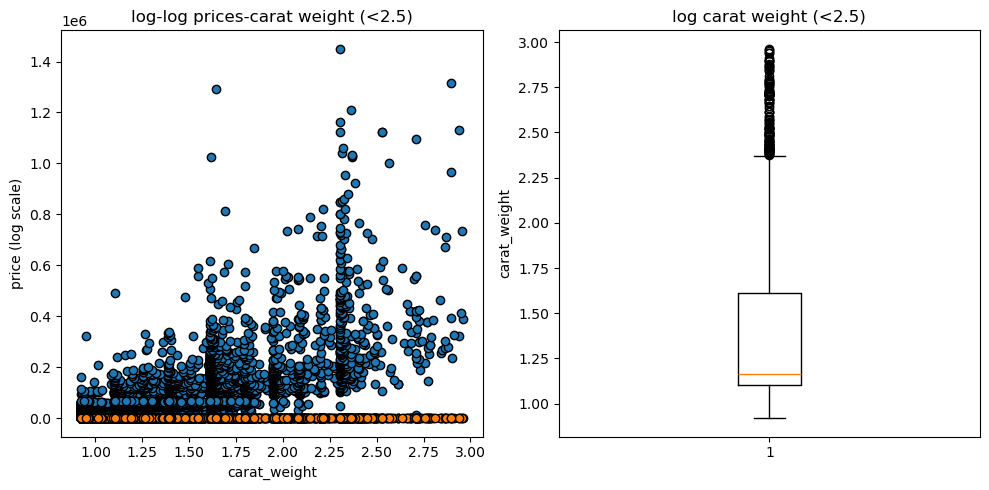

In [38]:
# Create the Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Histogram
ax1.scatter(x=super_90['log_cw'], y=super_90['total_sales_price'],  edgecolor='black')

# Histogram
ax1.scatter(x=super_90['log_cw'], y=super_90['log_price'],  edgecolor='black')
ax1.set_xlabel('carat_weight')
ax1.set_ylabel('price (log scale)')
ax1.set_title('log-log prices-carat weight (>2.5)')

# Box Plot (Whiskers)
ax2.boxplot(super_90['log_cw'])
ax2.set_ylabel('carat_weight')
ax2.set_title('log carat weight (>2.5)')

# Adjust Layout
plt.tight_layout()

# Display the Plots
plt.show()

## Preparing the model 

In [31]:

def preprocess_data(df, target_col='total_sales_price', test_size=.2, val_size=0.25, random_state=1):
    """
        Preprocess the dataset by splitting it into training, validation, and test sets, 
        and separating the target variable. Default is 60/20/20 split
    
        Parameters:
        df (pd.DataFrame): The input dataframe containing the dataset.
        target_col (str): The name of the target column. Default is 'y'.
        test_size (float): The proportion of the dataset to include in the test split. Default is 0.2.
        val_size (float): The proportion of the training set to include in the validation split. Default is 0.25.
        random_state (int): The random seed used for shuffling the data. Default is 42.
    
        Returns:
        tuple: A tuple containing:
            - df_train (pd.DataFrame): The training set with the target column removed.
            - df_val (pd.DataFrame): The validation set with the target column removed.
            - df_test (pd.DataFrame): The test set with the target column removed.
            - y_train (pd.Series): The target values for the training set.
            - y_val (pd.Series): The target values for the validation set.
            - y_test (pd.Series): The target values for the test set.
        """
    
    df_full_train, df_test = train_test_split(df, test_size=test_size, random_state=random_state)
    df_train, df_val = train_test_split(df_full_train, test_size=val_size, random_state=random_state)
    
    # Reset indices and separate target variable
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    y_train = df_train.pop(target_col)
    y_val = df_val.pop(target_col)
    y_test = df_test.pop(target_col)
    
    return df_train, df_val, df_test, y_train, y_val, y_test

# Example usage:
#df_train, df_val, df_test, y_train, y_val, y_test = preprocess_data(df, target_col='jamb_score', random_state=1)


In [32]:
df_train, df_val, df_test, y_train, y_val, y_test = preprocess_data(df, target_col='total_sales_price', test_size=.2, val_size=0.25, random_state=1)

In [33]:
len(df_train), len(df_val), len(df_test)

(131822, 43941, 43941)

In [34]:
## Make and run the pipeline

In [35]:
# nominal_pipeline = Pipeline(
#     steps=[("onehot", OneHotEncoder(handle_unknown="ignore")) ])
 
# clarity_pipeline = Pipeline(
#     steps=[("encoder", OrdinalEncoder()) ])

# culet_size_pipeline = Pipeline(
#     steps=[("encoder", OrdinalEncoder()) ])

# cut_quality_pipeline = Pipeline(
#     steps=[("encoder", OrdinalEncoder()) ])

# polish_pipeline = Pipeline(
#     steps=[("encoder", OrdinalEncoder()) ])

# symmetry_pipeline = Pipeline(
#     steps=[("encoder", OrdinalEncoder()) ])